# Wine Classification

## Machine Learning Classification Project

This project uses the Wine Recognition dataset from scikit-learn to classify wines into three different categories based on their chemical characteristics.

### Project objectives

- Explore and understand the dataset
- Analyze the distribution of wine classes
- Prepare the data for machine learning
- Compare different classification algorithms
- Evaluate model performance
- Save the best trained model
- Build an interactive application with Streamlit

In [ ]:
import os
import sys
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

print("Libraries imported successfully")
print("Python version:", sys.version)

In [1]:
print("Kernel funcionando")

Kernel funcionando


In [2]:
import os
import sys
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

print("Libraries imported successfully")
print("Python version:", sys.version)

Libraries imported successfully
Python version: 3.12.3 (tags/v3.12.3:f6650f9, Apr  9 2024, 14:05:25) [MSC v.1938 64 bit (AMD64)]


In [3]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

df = X.copy()
df["target"] = y

class_names = wine.target_names
feature_names = wine.feature_names

print("Dataset loaded successfully")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Wine classes:", class_names)

Dataset loaded successfully
Number of rows: 178
Number of columns: 14
Wine classes: ['class_0' 'class_1' 'class_2']


In [4]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
for column in df.columns:
    print("-", column)

Dataset shape: (178, 14)

Column names:
- alcohol
- malic_acid
- ash
- alcalinity_of_ash
- magnesium
- total_phenols
- flavanoids
- nonflavanoid_phenols
- proanthocyanins
- color_intensity
- hue
- od280/od315_of_diluted_wines
- proline
- target


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [7]:
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values per column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

Total missing values: 0


In [8]:
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [10]:
class_distribution = df["target"].value_counts().sort_index()

class_distribution.index = [
    class_names[class_index]
    for class_index in class_distribution.index
]

print("Class distribution:")
print(class_distribution)

Class distribution:
class_0    59
class_1    71
class_2    48
Name: count, dtype: int64


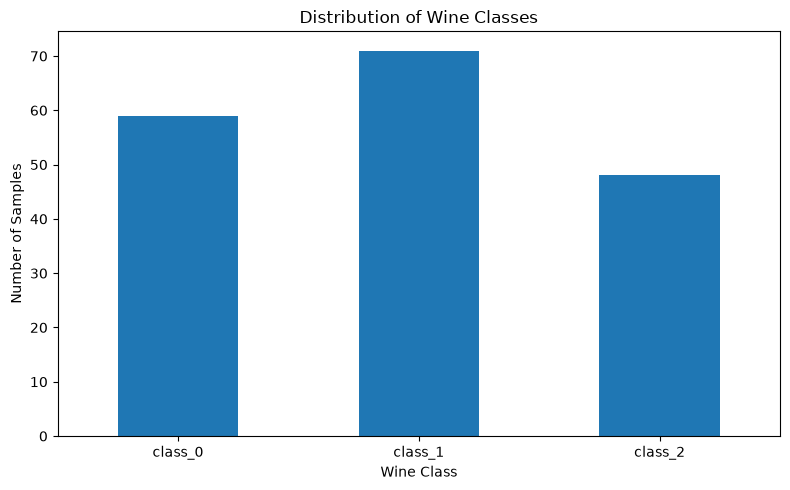

In [11]:
plt.figure(figsize=(8, 5))

class_distribution.plot(kind="bar")

plt.title("Distribution of Wine Classes")
plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

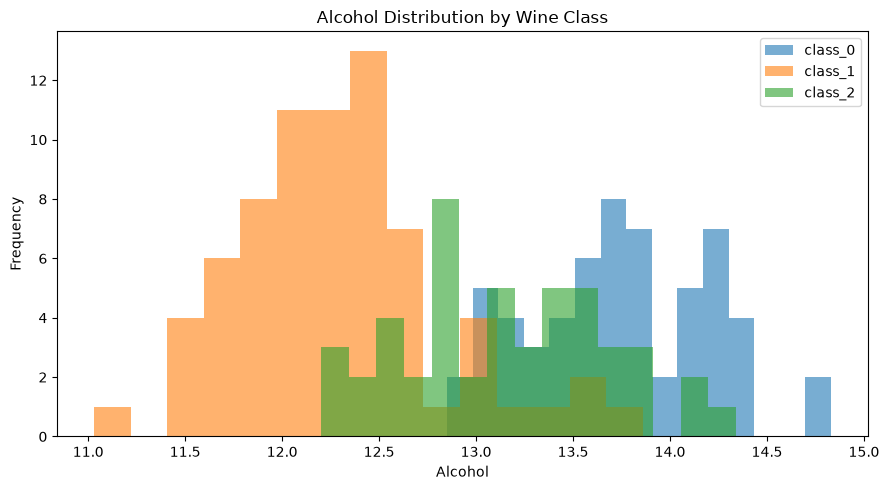

In [12]:
plt.figure(figsize=(9, 5))

for class_index, class_name in enumerate(class_names):
    class_data = df[df["target"] == class_index]["alcohol"]

    plt.hist(
        class_data,
        bins=15,
        alpha=0.6,
        label=class_name
    )

plt.title("Alcohol Distribution by Wine Class")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
class_feature_means = df.groupby("target").mean()

class_feature_means.index = class_names

class_feature_means

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
class_0,13.744746,2.010678,2.455593,17.037288,106.338983,2.840169,2.982373,0.290000,1.899322,5.528305,1.062034,3.157797,1115.711864
class_1,12.278732,1.932676,2.244789,20.238028,94.549296,2.258873,2.080845,0.363662,1.630282,3.086620,1.056282,2.785352,519.507042
class_2,13.153750,3.333750,2.437083,21.416667,99.312500,1.678750,0.781458,0.447500,1.153542,7.396250,0.682708,1.683542,629.895833


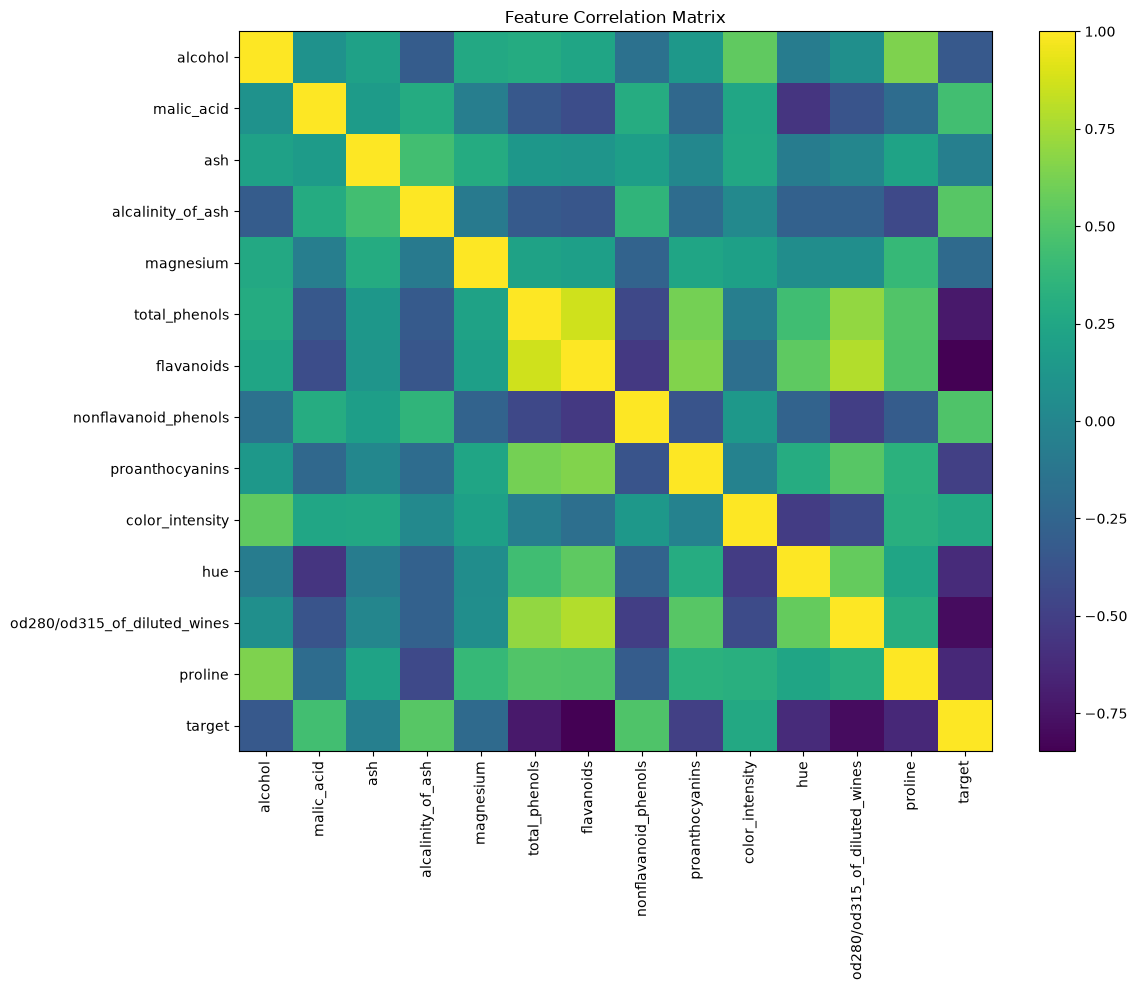

In [14]:
correlation_matrix = df.corr()

plt.figure(figsize=(12, 10))

correlation_plot = plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(correlation_plot)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [15]:
X = df.drop(columns="target")
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (178, 13)
Target shape: (178,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (142, 13)
Testing features: (36, 13)
Training target: (142,)
Testing target: (36,)


In [17]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(
            n_neighbors=5
        ))
    ]),

    "Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    )
}

print("Models created successfully:")

for model_name in models:
    print("-", model_name)

Models created successfully:
- Logistic Regression
- K-Nearest Neighbors
- Support Vector Machine
- Random Forest


In [18]:
model_results = []

for model_name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    model_results.append({
        "Model": model_name,
        "Mean Accuracy": scores.mean(),
        "Standard Deviation": scores.std()
    })

    print(f"{model_name}")
    print(f"Mean accuracy: {scores.mean():.4f}")
    print(f"Standard deviation: {scores.std():.4f}")
    print("-" * 40)

Logistic Regression
Mean accuracy: 0.9931
Standard deviation: 0.0138
----------------------------------------
K-Nearest Neighbors
Mean accuracy: 0.9650
Standard deviation: 0.0378
----------------------------------------
Support Vector Machine
Mean accuracy: 0.9862
Standard deviation: 0.0276
----------------------------------------
Random Forest
Mean accuracy: 0.9862
Standard deviation: 0.0276
----------------------------------------


In [19]:
results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="Mean Accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Mean Accuracy,Standard Deviation
0,Logistic Regression,0.993103,0.013793
1,Support Vector Machine,0.986207,0.027586
2,Random Forest,0.986207,0.027586
3,K-Nearest Neighbors,0.965025,0.037779


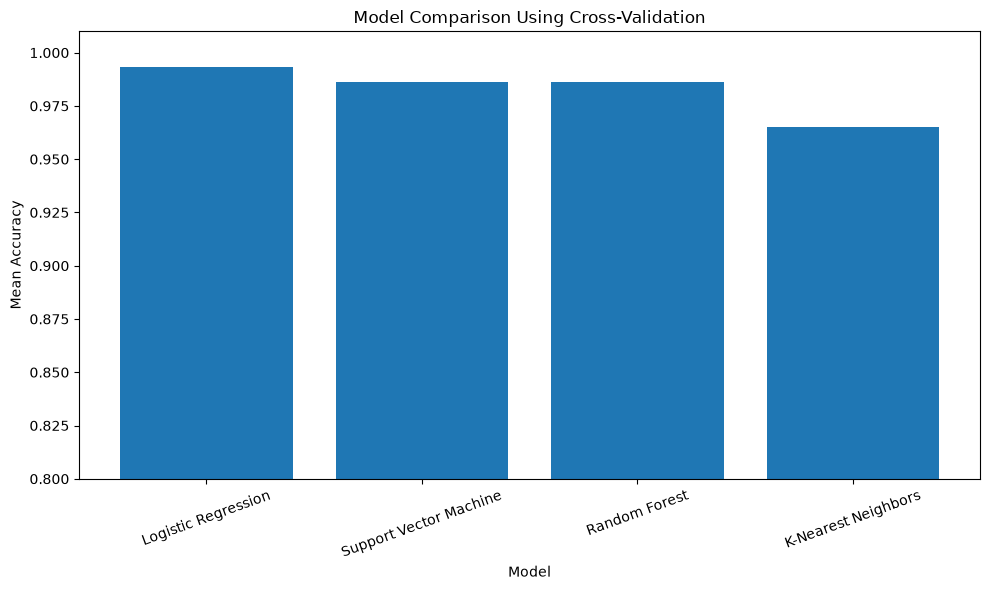

In [20]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["Mean Accuracy"]
)

plt.title("Model Comparison Using Cross-Validation")
plt.xlabel("Model")
plt.ylabel("Mean Accuracy")
plt.ylim(0.80, 1.01)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [21]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best model:", best_model_name)

Best model: Logistic Regression


In [22]:
best_model.fit(X_train, y_train)

print("Best model trained successfully")

Best model trained successfully


In [23]:
y_pred = best_model.predict(X_test)

print("Predictions generated successfully")
print("Number of predictions:", len(y_pred))

Predictions generated successfully
Number of predictions: 36


In [24]:
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test accuracy percentage: {test_accuracy * 100:.2f}%")

Test accuracy: 0.9722
Test accuracy percentage: 97.22%


In [25]:
report = classification_report(
    y_test,
    y_pred,
    target_names=class_names
)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [26]:
conf_matrix = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]


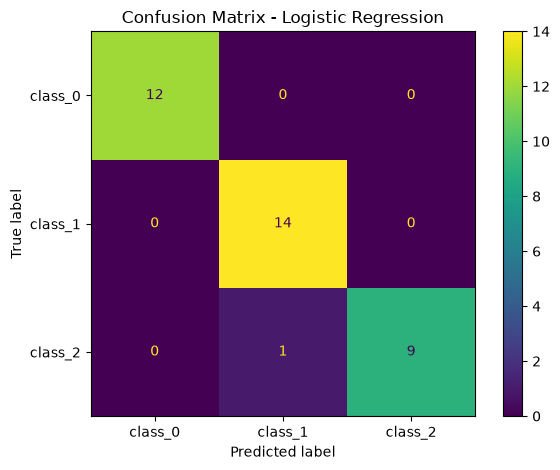

In [27]:
display = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=class_names
)

display.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

In [28]:
prediction_results = pd.DataFrame({
    "Actual Class": y_test.values,
    "Predicted Class": y_pred
})

prediction_results["Actual Name"] = prediction_results["Actual Class"].map(
    lambda class_index: class_names[class_index]
)

prediction_results["Predicted Name"] = prediction_results["Predicted Class"].map(
    lambda class_index: class_names[class_index]
)

prediction_results.head(15)

,Actual Class,Predicted Class,Actual Name,Predicted Name
0,0,0,class_0,class_0
1,2,1,class_2,class_1
2,0,0,class_0,class_0
3,1,1,class_1,class_1
4,1,1,class_1,class_1
5,0,0,class_0,class_0
6,0,0,class_0,class_0
7,1,1,class_1,class_1
8,1,1,class_1,class_1
9,2,2,class_2,class_2


In [29]:
incorrect_predictions = prediction_results[
    prediction_results["Actual Class"]
    != prediction_results["Predicted Class"]
]

print("Incorrect predictions:", len(incorrect_predictions))

incorrect_predictions

Incorrect predictions: 1


,Actual Class,Predicted Class,Actual Name,Predicted Name
1,2,1,class_2,class_1


In [30]:
sample_index = 0

sample = X_test.iloc[[sample_index]]
actual_class = y_test.iloc[sample_index]
predicted_class = best_model.predict(sample)[0]

print("Actual class:", class_names[actual_class])
print("Predicted class:", class_names[predicted_class])

Actual class: class_0
Predicted class: class_0


In [31]:
prediction_probabilities = best_model.predict_proba(sample)[0]

probability_results = pd.DataFrame({
    "Wine Class": class_names,
    "Probability": prediction_probabilities
})

probability_results["Probability Percentage"] = (
    probability_results["Probability"] * 100
).round(2)

probability_results

,Wine Class,Probability,Probability Percentage
0,class_0,0.999671,99.97
1,class_1,0.000307,0.03
2,class_2,0.000023,0.00


In [32]:
model_path = "../models/wine_classification_model.joblib"

joblib.dump(best_model, model_path)

print("Model saved successfully")
print("Model path:", model_path)

Model saved successfully
Model path: ../models/wine_classification_model.joblib


In [33]:
metadata = {
    "feature_names": list(feature_names),
    "class_names": list(class_names),
    "best_model_name": best_model_name,
    "test_accuracy": float(test_accuracy)
}

metadata_path = "../models/wine_metadata.joblib"

joblib.dump(metadata, metadata_path)

print("Metadata saved successfully")
print("Metadata path:", metadata_path)

Metadata saved successfully
Metadata path: ../models/wine_metadata.joblib


In [34]:
loaded_model = joblib.load("../models/wine_classification_model.joblib")
loaded_metadata = joblib.load("../models/wine_metadata.joblib")

loaded_prediction = loaded_model.predict(sample)[0]

print("Loaded model prediction:", loaded_metadata["class_names"][loaded_prediction])
print("Saved model:", loaded_metadata["best_model_name"])
print(f"Saved accuracy: {loaded_metadata['test_accuracy'] * 100:.2f}%")

Loaded model prediction: class_0
Saved model: Logistic Regression
Saved accuracy: 97.22%


## Conclusion

The Wine Classification project successfully compared four machine learning algorithms:

- Logistic Regression
- K-Nearest Neighbors
- Support Vector Machine
- Random Forest

Logistic Regression achieved the best cross-validation performance and was selected as the final model.

The final model was evaluated using unseen test data through accuracy, precision, recall, F1-score, and a confusion matrix.

The trained model and its metadata were saved successfully and can now be integrated into an interactive Streamlit application.